In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Cookbook_Trajectory_Performance_Analysis)=
# Trajectory Analysis

*Calculating RMSD, RMSF, and radius of gyration time series across trajectory structures.*

Analyzing structural stability and conformational dynamics across thousands of trajectory frames requires high-performance analytical routines. MolSysMT provides vector-accelerated and multi-threaded analytical functions for core metrics like RMSD, RMSF, and Radius of Gyration.

In this recipe, we analyze a solvated Villin Headpiece trajectory, compute structural observables, and generate a stability summary plot.

:::{versionadded} 1.0.0
:::


## Loading Trajectory

We load the topology and trajectory files for the Villin Headpiece (HP35) and configure multi-threading:

In [2]:
import molsysmt as msm
import numpy as np
import matplotlib.pyplot as plt

# Load solvated trajectory
topology = msm.systems['chicken villin HP35']['chicken_villin_HP35_solvated.h5msm']
trajectory = msm.systems['chicken villin HP35']['traj_chicken_villin_HP35_solvated.dcd']
molsys = msm.convert([topology, trajectory], to_form='molsysmt.MolSys')

# Configure parallel execution
msm.configure.set_parallelization(parallel='auto', num_threads=4)
print(f"Loaded {msm.get(molsys, n_structures=True)} structures with {msm.get(molsys, n_atoms=True)} atoms.")

Loaded 20 structures with 4369 atoms.


## Calculating RMSD

We calculate the C-alpha and backbone RMSD time series relative to the initial structure (frame 0):

In [3]:
# Compute C-alpha RMSD
rmsd_ca = msm.structure.get_rmsd(
    molsys,
    selection='atom_name=="CA"',
    reference_structure_index=0
)

# Compute all heavy-atom backbone RMSD
rmsd_bb = msm.structure.get_rmsd(
    molsys,
    selection='backbone',
    reference_structure_index=0
)

print(f"C-alpha RMSD: mean = {np.mean(rmsd_ca):.3f} nm, max = {np.max(rmsd_ca):.3f} nm")

C-alpha RMSD: mean = 3.168 nanometer nm, max = 4.166 nanometer nm


## Calculating RMSF

We compute per-residue fluctuations to identify flexible loops versus stable secondary structure elements:

In [4]:
# Compute C-alpha RMSF per residue
rmsf_ca = msm.structure.get_rmsf(
    molsys,
    selection='atom_name=="CA"'
)
residue_indices = np.arange(len(rmsf_ca))
print(f"RMSF calculated for {len(rmsf_ca)} residues.")

RMSF calculated for 36 residues.


## Calculating Radius of Gyration

We compute the compactness of the protein across the trajectory using {func}`molsysmt.structure.get_radius_of_gyration`:

In [5]:
# Compute protein radius of gyration
rg = msm.structure.get_radius_of_gyration(
    molsys,
    selection='group_type=="amino acid"'
)
print(f"Radius of Gyration: mean = {np.mean(rg):.3f} nm")

Radius of Gyration: mean = 0.944 nanometer nm


## Plotting Structural Observables

We summarize the structural observables in a 3-panel figure:

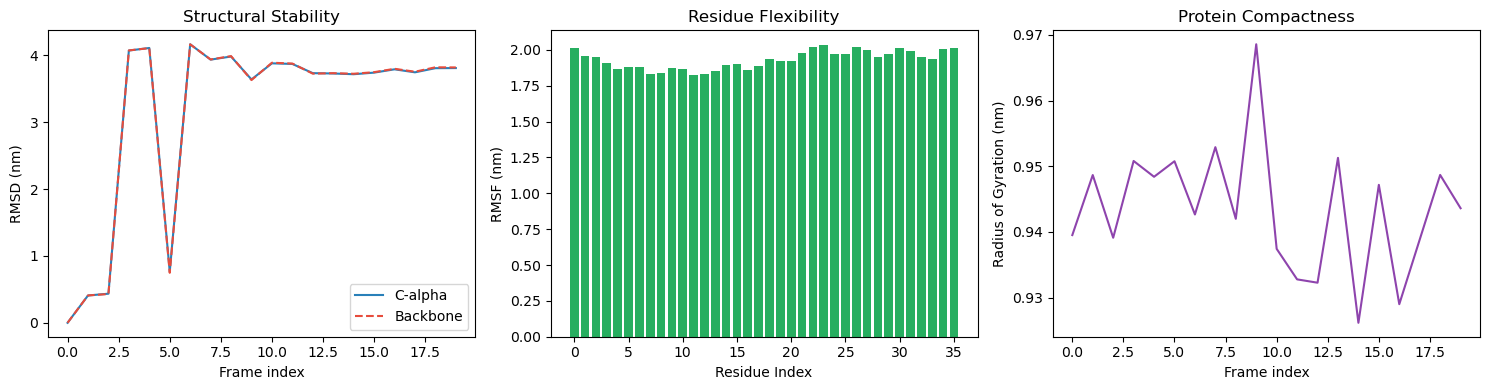

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
frames = np.arange(len(rmsd_ca))

# Panel 1: RMSD Time Series
axes[0].plot(frames, msm.pyunitwizard.get_value(rmsd_ca, to_unit='nm'), label='C-alpha', color='#2980B9')
axes[0].plot(frames, msm.pyunitwizard.get_value(rmsd_bb, to_unit='nm'), label='Backbone', color='#E74C3C', linestyle='--')
axes[0].set_xlabel('Frame index')
axes[0].set_ylabel('RMSD (nm)')
axes[0].set_title('Structural Stability')
axes[0].legend()

# Panel 2: RMSF Fluctuation Profile
axes[1].bar(residue_indices, msm.pyunitwizard.get_value(rmsf_ca, to_unit='nm'), color='#27AE60')
axes[1].set_xlabel('Residue Index')
axes[1].set_ylabel('RMSF (nm)')
axes[1].set_title('Residue Flexibility')

# Panel 3: Radius of Gyration
axes[2].plot(frames, msm.pyunitwizard.get_value(rg, to_unit='nm'), color='#8E44AD')
axes[2].set_xlabel('Frame index')
axes[2].set_ylabel('Radius of Gyration (nm)')
axes[2].set_title('Protein Compactness')

plt.tight_layout()
plt.show()

:::{seealso}
:class: dropdown

- {func}`molsysmt.structure.get_rmsd`: Computing RMSD time series.
- {func}`molsysmt.structure.get_rmsf`: Computing per-residue RMSF profiles.
- {func}`molsysmt.structure.get_radius_of_gyration`: Computing radius of gyration time series.
:::